<a href="https://colab.research.google.com/github/silviaparente/computational_astrobiology/blob/main/Copia%20di%20CUDA_for_ML_Master_Colab_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CUDA Programming for Machine Learning — Google Colab Notebook

This notebook is a **master-level primer** on CUDA for machine learning students.
It is designed for **Google Colab with GPU enabled**.

## How to use this notebook in Colab
1. Open the notebook in Google Colab.
2. Go to **Runtime → Change runtime type**.
3. Set **Hardware accelerator = GPU**.
4. Run the cells from top to bottom.

## Learning goals
By the end of this notebook, you should be able to:
- explain **host vs device** execution,
- understand **threads, blocks, grids, and warps**,
- derive the standard **CUDA indexing formulas**,
- measure GPU code **correctly** using synchronization,
- understand why **memory traffic** can dominate runtime,
- connect CUDA ideas to **PyTorch** workloads used in machine learning.

This notebook emphasizes **intuition, derivations, and reproducible experiments**.

In [1]:
# Basic imports
import os
import math
import time
import statistics
from typing import Callable, List

import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("CUDA device count:", torch.cuda.device_count())
    print("Current device:", torch.cuda.current_device())
    print("Device name:", torch.cuda.get_device_name(torch.cuda.current_device()))
else:
    print("No CUDA device found. In Colab, switch runtime to GPU.")

PyTorch version: 2.11.0+cu128
CUDA available: True
CUDA device count: 1
Current device: 0
Device name: Tesla T4


## 1. Host and device

In CUDA language:

- **Host** = CPU side
- **Device** = GPU side

A standard GPU workflow looks like this:

1. allocate / prepare data on the host,
2. copy data to device,
3. launch a GPU kernel,
4. possibly copy results back,
5. continue on host or keep everything on device.

In PyTorch this is often hidden behind:

```python
x = x.to("cuda")
```

but the transfer still exists and can be expensive.

In [2]:
# Helper for choosing device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

## 2. Why timing GPU code is subtle

CUDA launches are usually **asynchronous**.
That means the CPU may continue before the GPU finishes.

Therefore, naive timing like:

```python
t0 = time.time()
y = x @ w
t1 = time.time()
```

can be misleading.

We need `torch.cuda.synchronize()` before stopping the timer.

In [3]:
def benchmark(fn: Callable, warmup: int = 10, iters: int = 50, label: str = "benchmark"):
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    for _ in range(warmup):
        fn()
    if torch.cuda.is_available():
        torch.cuda.synchronize()

    times = []
    for _ in range(iters):
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        t0 = time.perf_counter()
        fn()
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        t1 = time.perf_counter()
        times.append((t1 - t0) * 1e3)  # ms

    print(f"{label}: mean={statistics.mean(times):.3f} ms | median={statistics.median(times):.3f} ms | min={min(times):.3f} ms | max={max(times):.3f} ms")
    return times

In [4]:
# Demonstration: CPU vs GPU matmul timing
n = 2048

x_cpu = torch.randn(n, n)
w_cpu = torch.randn(n, n)

def cpu_mm():
    return x_cpu @ w_cpu

cpu_times = benchmark(cpu_mm, warmup=3, iters=10, label="CPU matmul")

if torch.cuda.is_available():
    x_gpu = x_cpu.to("cuda")
    w_gpu = w_cpu.to("cuda")

    def gpu_mm():
        return x_gpu @ w_gpu

    gpu_times = benchmark(gpu_mm, warmup=5, iters=20, label="GPU matmul")

CPU matmul: mean=190.875 ms | median=190.631 ms | min=180.227 ms | max=206.312 ms
GPU matmul: mean=6.023 ms | median=5.944 ms | min=5.908 ms | max=6.243 ms


## 3. CUDA execution hierarchy

A CUDA kernel is launched over a hierarchy:

- **thread**
- **block**
- **grid**

### Standard 1D indexing derivation

Suppose:
- each block contains `blockDim.x = B` threads,
- blocks are numbered `blockIdx.x = 0, 1, 2, ...`,
- threads within a block are numbered `threadIdx.x = 0, 1, ..., B-1`.

Then block `b` owns the global index range:

\[
bB, (bB+1), \dots, (bB+B-1)
\]

So thread `t` inside block `b` has global index

\[
i = bB + t
\]

In CUDA notation:

```cpp
int idx = blockIdx.x * blockDim.x + threadIdx.x;
```

This is the single most important indexing formula in introductory CUDA.

In [5]:
def global_index_1d(block_idx, block_dim, thread_idx):
    return block_idx * block_dim + thread_idx

B = 8
for b in range(3):
    idxs = [global_index_1d(b, B, t) for t in range(B)]
    print(f"block {b}: {idxs}")

block 0: [0, 1, 2, 3, 4, 5, 6, 7]
block 1: [8, 9, 10, 11, 12, 13, 14, 15]
block 2: [16, 17, 18, 19, 20, 21, 22, 23]


### Why do we need a bounds check?

If we launch more threads than data items, some threads would try to access invalid memory.

For an array of length `N`, the standard CUDA pattern is:

```cpp
int idx = blockIdx.x * blockDim.x + threadIdx.x;
if (idx < N) {
    // safe access
}
```

The `if` guard is not optional. It is what lets us use convenient launch sizes without requiring that `N` be an exact multiple of block size.

## 4. Grid-size formula and ceiling division

If each block handles `B` elements, and we must cover `N` total elements, then the number of blocks must satisfy

\[
\text{grid} \cdot B \ge N
\]

The smallest such integer is

\[
\text{grid} = \left\lceil \frac{N}{B} \right\rceil
\]

In integer arithmetic, we use:

```cpp
grid = (N + B - 1) / B;
```

### Why does that work?

Write

\[
N = qB + r, \quad 0 \le r < B
\]

- if `r = 0`, then `N/B = q` exactly,
- if `r > 0`, we need `q+1` blocks.

Now compute:

\[
\frac{N + B - 1}{B} = \frac{qB + r + B - 1}{B}
\]

If `r = 0`, integer division gives `q`.
If `1 \le r \le B-1`, then `r + B - 1 \ge B`, so integer division gives `q+1`.

Hence this is exactly ceiling division.

In [6]:
def ceil_div(N, B):
    return (N + B - 1) // B

tests = [(1000, 256), (1024, 256), (1025, 256), (17, 8), (64, 32)]
for N, B in tests:
    print(f"N={N:4d}, B={B:3d} -> ceil_div={ceil_div(N,B):2d}, math.ceil={math.ceil(N/B):2d}")

N=1000, B=256 -> ceil_div= 4, math.ceil= 4
N=1024, B=256 -> ceil_div= 4, math.ceil= 4
N=1025, B=256 -> ceil_div= 5, math.ceil= 5
N=  17, B=  8 -> ceil_div= 3, math.ceil= 3
N=  64, B= 32 -> ceil_div= 2, math.ceil= 2


## 5. 2D indexing and flattening

Machine learning tensors are often matrices or images.

For a 2D launch:

```cpp
int row = blockIdx.y * blockDim.y + threadIdx.y;
int col = blockIdx.x * blockDim.x + threadIdx.x;
```

If a matrix has shape `(H, W)`, then a row-major flattened index is

\[
\text{flat} = row \cdot W + col
\]

### Why?

Each full row contains `W` elements.
So before row `row`, there are already `row · W` elements.
Then `col` steps move within the row.

In [7]:
def flatten_2d(row, col, width):
    return row * width + col

H, W = 3, 5
for row in range(H):
    vals = [flatten_2d(row, col, W) for col in range(W)]
    print(f"row {row}: {vals}")

row 0: [0, 1, 2, 3, 4]
row 1: [5, 6, 7, 8, 9]
row 2: [10, 11, 12, 13, 14]


## 6. 3D indexing and tensor intuition

For a 3D tensor with shape `(D, H, W)` in row-major order:

\[
\text{flat} = d(HW) + hW + w
\]

This follows the same logic:
- each depth slice contains `H·W` values,
- each row within a slice contributes `W` values,
- `w` indexes within the row.

This kind of flattening matters because device memory is linear even when the tensor is logically multidimensional.

In [8]:
def flatten_3d(d, h, w, H, W):
    return d * H * W + h * W + w

D, H, W = 2, 3, 4
for d in range(D):
    print(f"depth {d}")
    for h in range(H):
        vals = [flatten_3d(d, h, w, H, W) for w in range(W)]
        print("  ", vals)

depth 0
   [0, 1, 2, 3]
   [4, 5, 6, 7]
   [8, 9, 10, 11]
depth 1
   [12, 13, 14, 15]
   [16, 17, 18, 19]
   [20, 21, 22, 23]


## 7. Warps and SIMT

On NVIDIA GPUs, threads are executed in groups of **32**, called **warps**.

This leads to the **SIMT** model: Single Instruction, Multiple Threads.

### Divergence
If all threads in a warp follow the same control path, execution is efficient.
If some threads take one branch and others another branch, the warp may execute both paths serially.

A simplified cost model:

- if all 32 threads follow one branch: cost \(\sim T\)
- if half follow branch A and half branch B: cost can become \(\sim T_A + T_B\)

So divergence reduces effective throughput.

This matters in ML for:
- masking,
- sparse routing,
- variable-length sequence logic,
- conditional kernels.

In [9]:
# Simple conceptual demonstration using PyTorch masks
# This is not a raw warp-level experiment, but it illustrates branching-heavy vs branch-free logic.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
N = 20_000_000
x = torch.randn(N, device=device)

def branchy():
    y = torch.empty_like(x)
    pos = x > 0
    y[pos] = x[pos]
    y[~pos] = 0.01 * x[~pos]
    return y

def branch_free():
    return torch.where(x > 0, x, 0.01 * x)

if torch.cuda.is_available():
    benchmark(branchy, warmup=5, iters=20, label="branchy leaky-relu style")
    benchmark(branch_free, warmup=5, iters=20, label="branch-free torch.where style")
else:
    print("Run on GPU runtime for a better CUDA-oriented comparison.")

branchy leaky-relu style: mean=8.533 ms | median=8.275 ms | min=8.054 ms | max=9.047 ms
branch-free torch.where style: mean=2.122 ms | median=2.121 ms | min=2.115 ms | max=2.154 ms


## 8. CUDA memory hierarchy

A simplified hierarchy:

1. **Registers** — fastest, private to each thread
2. **Shared memory** — fast, shared within a block
3. **Global memory** — large but high-latency, lives in VRAM

### ML interpretation
- model weights, activations, gradients: usually in **global memory**
- reusable tiles for GEMM or convolution: often placed in **shared memory**
- thread-local accumulators and temporary scalars: live in **registers**

A major lesson of CUDA programming is:

> Performance is often limited not by arithmetic, but by how efficiently data moves.

## 9. Memory-bound vs compute-bound workloads

A first-order runtime model is:

\[
T \approx \max\left( \frac{\text{bytes moved}}{BW}, \frac{\text{flops}}{F} \right)
\]

where:
- \(BW\) = achievable memory bandwidth,
- \(F\) = achievable compute throughput.

This means runtime is dominated by whichever resource is the bottleneck.

### Arithmetic intensity

Define arithmetic intensity as

\[
AI = \frac{\text{flops}}{\text{bytes moved}}
\]

Then:
- low \(AI\) → usually **memory-bound**
- high \(AI\) → can become **compute-bound**

### Why fusion helps
Suppose two elementwise kernels each load and store tensors separately.
Fusing them may keep intermediates in registers, reducing bytes moved and increasing \(AI\).
This is one reason fused ML kernels can be much faster.

In [10]:
def estimate_runtime(bytes_moved, flops, bandwidth_bytes_per_s, flop_rate_per_s):
    t_mem = bytes_moved / bandwidth_bytes_per_s
    t_cmp = flops / flop_rate_per_s
    return t_mem, t_cmp, max(t_mem, t_cmp)

# Toy numbers for demonstration
bytes_moved = 8e9      # 8 GB
flops = 2e12           # 2 TFLOPs of work
bandwidth = 8e11       # 800 GB/s
flop_rate = 2e13       # 20 TFLOP/s

t_mem, t_cmp, t_total = estimate_runtime(bytes_moved, flops, bandwidth, flop_rate)
print(f"memory time   = {t_mem:.6f} s")
print(f"compute time  = {t_cmp:.6f} s")
print(f"predicted T   = {t_total:.6f} s")
print("Interpretation: bottleneck =", "memory" if t_mem > t_cmp else "compute")

memory time   = 0.010000 s
compute time  = 0.100000 s
predicted T   = 0.100000 s
Interpretation: bottleneck = compute


## 10. Example: elementwise square is often memory-dominated

For `y = x * x` in FP32:
- read `x`: 4 bytes
- write `y`: 4 bytes
- total bytes per element ≈ 8 bytes
- flops per element ≈ 1 multiplication

So arithmetic intensity is approximately

\[
AI \approx \frac{1}{8} \text{ flop/byte}
\]

That is very low.
Hence simple elementwise kernels are often limited by **memory bandwidth**, not compute throughput.

In [11]:
# Empirical experiment: square on a large tensor
N = 50_000_000  # ~200 MB FP32 input
x = torch.randn(N, device=device)

def square_op():
    return x * x

times = benchmark(square_op, warmup=5, iters=20, label="large elementwise square")

# Approximate achieved bandwidth
if torch.cuda.is_available():
    avg_ms = statistics.mean(times)
    bytes_per_element = 8  # read x + write y
    total_bytes = N * bytes_per_element
    achieved_bw = total_bytes / (avg_ms * 1e-3) / 1e9
    print(f"Approx achieved bandwidth: {achieved_bw:.2f} GB/s")

large elementwise square: mean=1.740 ms | median=1.744 ms | min=1.716 ms | max=1.769 ms
Approx achieved bandwidth: 229.83 GB/s


## 11. Matrix multiplication and why GPUs shine there

For matrix multiplication \(C = AB\), each output element is

\[
C_{ij} = \sum_{k=1}^{K} A_{ik} B_{kj}
\]

This has much higher arithmetic intensity than a simple elementwise transform,
especially when data reuse is exploited.

### Tiling intuition
A block loads tiles of \(A\) and \(B\) into shared memory.
Threads then reuse those tiles many times before loading the next tile.

This increases arithmetic intensity and is one of the reasons GEMM is the workhorse of deep learning performance.

In [12]:
# Compare an elementwise op and matmul
n = 4096
a = torch.randn(n, n, device=device)
b = torch.randn(n, n, device=device)

def elemwise():
    return a * a + 2.0 * a

def mm():
    return a @ b

if torch.cuda.is_available():
    benchmark(elemwise, warmup=3, iters=10, label="elementwise fused expression")
    benchmark(mm, warmup=3, iters=10, label="matrix multiplication")

elementwise fused expression: mean=2.034 ms | median=2.031 ms | min=2.025 ms | max=2.048 ms
matrix multiplication: mean=33.948 ms | median=33.249 ms | min=32.867 ms | max=39.351 ms


## 12. Softmax: a numerically stable derivation

Naive softmax is

\[
\operatorname{softmax}(x_i) = \frac{e^{x_i}}{\sum_j e^{x_j}}
\]

But this can overflow if some \(x_i\) is large.

### Stabilized form
Let \(m = \max_j x_j\). Then:

\[
\frac{e^{x_i}}{\sum_j e^{x_j}}
=
\frac{e^{x_i-m}}{\sum_j e^{x_j-m}}
\]

because multiplying numerator and denominator by \(e^{-m}\) does not change the ratio.

Now all exponents are \(\le 0\), which is much safer numerically.

### CUDA relevance
Efficient softmax kernels typically involve:
- a reduction for the max,
- a reduction for the sum of exponentials,
- careful memory access,
- often kernel fusion.

In [13]:
# Stable softmax demo
x = torch.tensor([1000.0, 1001.0, 1002.0], device=device)

stable = torch.softmax(x, dim=0)
print("Stable softmax from PyTorch:", stable)

# Manual stabilized version
m = x.max()
manual = torch.exp(x - m) / torch.exp(x - m).sum()
print("Manual stabilized softmax:", manual)

Stable softmax from PyTorch: tensor([0.0900, 0.2447, 0.6652], device='cuda:0')
Manual stabilized softmax: tensor([0.0900, 0.2447, 0.6652], device='cuda:0')


## 13. Attention scaling

In scaled dot-product attention:

\[
\operatorname{Attention}(Q,K,V) = \operatorname{softmax}\left( \frac{QK^T}{\sqrt{d_k}} \right)V
\]

### Why divide by \(\sqrt{d_k}\)?

If the components of queries and keys are roughly zero-mean with unit variance,
then the dot product

\[
q \cdot k = \sum_{r=1}^{d_k} q_r k_r
\]

has variance that grows roughly like \(d_k\).
So the magnitude of logits tends to grow with dimension.

Dividing by \(\sqrt{d_k}\) keeps the scale of logits more stable,
which helps softmax avoid becoming too sharp too early.

### CUDA relevance
Attention is a beautiful CUDA case study because it mixes:
- GEMM-like operations,
- reductions,
- softmax,
- heavy memory traffic,
- opportunities for fusion and tiling.

In [14]:
# Small attention demonstration in PyTorch
B, T, D = 2, 128, 64
Q = torch.randn(B, T, D, device=device)
K = torch.randn(B, T, D, device=device)
V = torch.randn(B, T, D, device=device)

def attention():
    scores = Q @ K.transpose(-2, -1) / math.sqrt(D)
    probs = torch.softmax(scores, dim=-1)
    out = probs @ V
    return out

if torch.cuda.is_available():
    benchmark(attention, warmup=5, iters=20, label="scaled dot-product attention toy example")
else:
    out = attention()
    print(out.shape)

scaled dot-product attention toy example: mean=0.114 ms | median=0.106 ms | min=0.100 ms | max=0.169 ms


## 14. Contiguity and memory layout

A tensor may be logically correct but physically laid out in memory in a way that hurts performance.

In PyTorch:
- `transpose` often creates a **view** with different strides,
- the tensor may become **non-contiguous**,
- some downstream kernels must handle strided access or create contiguous copies.

This connects directly to CUDA memory coalescing.

In [15]:
x = torch.randn(1024, 2048, device=device)
xt = x.t()

print("x.is_contiguous(): ", x.is_contiguous())
print("xt.is_contiguous():", xt.is_contiguous())

def use_contiguous():
    y = xt.contiguous()
    return y * 2.0

def use_noncontiguous():
    return xt * 2.0

if torch.cuda.is_available():
    benchmark(use_noncontiguous, warmup=5, iters=20, label="non-contiguous elementwise")
    benchmark(use_contiguous, warmup=5, iters=20, label="make contiguous then elementwise")

x.is_contiguous():  True
xt.is_contiguous(): False
non-contiguous elementwise: mean=0.114 ms | median=0.101 ms | min=0.087 ms | max=0.282 ms
make contiguous then elementwise: mean=0.202 ms | median=0.199 ms | min=0.195 ms | max=0.234 ms


## 15. Profiling in PyTorch

A profiler helps answer:
- Are we spending time in kernels or memory copies?
- Which op dominates runtime?
- Are we forcing synchronization accidentally?
- Are many tiny kernels causing overhead?

The cell below shows a minimal PyTorch profiler example.

In [16]:
if torch.cuda.is_available():
    from torch.profiler import profile, record_function, ProfilerActivity

    x = torch.randn(4096, 4096, device="cuda")
    y = torch.randn(4096, 4096, device="cuda")

    with profile(
        activities=[ProfilerActivity.CPU, ProfilerActivity.CUDA],
        record_shapes=True,
        profile_memory=True
    ) as prof:
        with record_function("matmul_then_relu"):
            z = x @ y
            z = torch.relu(z)

    print(prof.key_averages().table(sort_by="cuda_time_total", row_limit=12))
else:
    print("PyTorch profiler demo is most meaningful on GPU runtime.")

-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg       CPU Mem  Self CPU Mem      CUDA Mem  Self CUDA Mem    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                       matmul_then_relu         0.55%     278.395us         7.69%       3.864ms       3.864ms       0.000us         0.00%      96.078ms      96.078ms           0 B           0 B      64.00 MB     -64.00 M

/usr/local/lib/python3.12/dist-packages/torch/profiler/profiler.py:224: UserWarning: Warning: Profiler clears events at the end of each cycle.Only events from the current cycle will be reported.To keep events across cycles, set acc_events=True.
  _warn_once(


## 16. A note on kernel fusion

Suppose you compute:

```python
y = torch.relu(x + b)
```

A backend may:
1. launch one kernel for `x + b`,
2. write the result to memory,
3. launch another kernel for `relu`,
4. read and write again.

A fused kernel could:
- load once,
- compute both steps,
- store once.

This reduces memory traffic and launch overhead.

Fusion is one of the most important optimization ideas in modern ML systems.

In [17]:
# Simple comparison: separate steps vs one expression
x = torch.randn(20_000_000, device=device)
b = torch.randn(20_000_000, device=device)

def separate():
    t = x + b
    return torch.relu(t)

def fused_expr():
    return torch.relu(x + b)

if torch.cuda.is_available():
    benchmark(separate, warmup=5, iters=20, label="separate ops")
    benchmark(fused_expr, warmup=5, iters=20, label="single expression")

separate ops: mean=1.677 ms | median=1.670 ms | min=1.667 ms | max=1.714 ms
single expression: mean=1.675 ms | median=1.673 ms | min=1.666 ms | max=1.692 ms


## 17. Practical ML lessons from CUDA

Even if you never write a `.cu` file, CUDA knowledge helps you reason about:

1. why **small batch sizes** underutilize GPUs,
2. why **data transfers** hurt throughput,
3. why **`loss.item()`** can synchronize the device,
4. why **tensor layout** matters,
5. why **fusion** is valuable,
6. why some workloads are **memory-bound** and others **compute-bound**,
7. why a profiler is more trustworthy than intuition.

In [18]:
# Demonstration: .item() can force synchronization when used on GPU results
x = torch.randn(8192, 8192, device=device)

def without_item():
    y = (x @ x).sum()
    return y

def with_item():
    y = (x @ x).sum()
    return y.item()

if torch.cuda.is_available():
    benchmark(without_item, warmup=3, iters=10, label="sum without .item()")
    benchmark(with_item, warmup=3, iters=10, label="sum with .item()")

sum without .item(): mean=279.827 ms | median=279.398 ms | min=274.599 ms | max=289.737 ms
sum with .item(): mean=278.962 ms | median=278.740 ms | min=276.506 ms | max=281.496 ms


## 18. Optional advanced section: custom CUDA extension template

In research, one sometimes needs a custom fused operation that is not present in PyTorch.

Colab can compile extensions, but the environment may vary.
So the cell below is left **disabled by default**.
You can uncomment it if you want to experiment later.

The goal here is to show the workflow, not to force compilation in every runtime.

In [19]:
# OPTIONAL / ADVANCED
# Uncomment and try only if your Colab GPU runtime has the necessary compilation support.

# from torch.utils.cpp_extension import load_inline
#
# cpp_source = r'''
# #include <torch/extension.h>
# torch::Tensor identity_cuda(torch::Tensor x);
# torch::Tensor identity(torch::Tensor x) { return identity_cuda(x); }
# PYBIND11_MODULE(TORCH_EXTENSION_NAME, m) {
#     m.def("identity", &identity, "Identity wrapper");
# }
# '''
#
# cuda_source = r'''
# #include <torch/extension.h>
# torch::Tensor identity_cuda(torch::Tensor x) {
#     return x.clone();
# }
# '''
#
# module = load_inline(
#     name="identity_ext_demo",
#     cpp_sources=cpp_source,
#     cuda_sources=cuda_source,
#     functions=None,
#     extra_cuda_cflags=[],
#     verbose=True,
# )
#
# x = torch.randn(8, device="cuda")
# print(module.identity(x))

## 19. Exercises

### Exercise 1
Derive again why

\[
\text{idx} = blockIdx.x \cdot blockDim.x + threadIdx.x
\]

is the correct global thread index in a 1D launch.

### Exercise 2
Show why

\[
\left\lceil \frac{N}{B} \right\rceil = \frac{N+B-1}{B}
\]

under integer division.

### Exercise 3
For a tensor with shape `(D, H, W)`, derive the flattening rule.

### Exercise 4
Why is a large elementwise square often memory-bound?

### Exercise 5
Why does GEMM usually benefit more from GPUs than scalar-heavy logic?

### Exercise 6
Why does dividing attention logits by \(\sqrt{d_k}\) help?

### Exercise 7
Use the profiler on a small neural network and identify the dominant operator.

### Exercise 8
Compare runtime for contiguous and non-contiguous tensors in your own experiment.

Benchmarking non-contiguous...
Non-contiguous: mean=2.354 ms | median=2.346 ms | min=2.295 ms | max=2.408 ms
Benchmarking contiguous...
Contiguous: mean=7.272 ms | median=7.263 ms | min=7.219 ms | max=7.349 ms


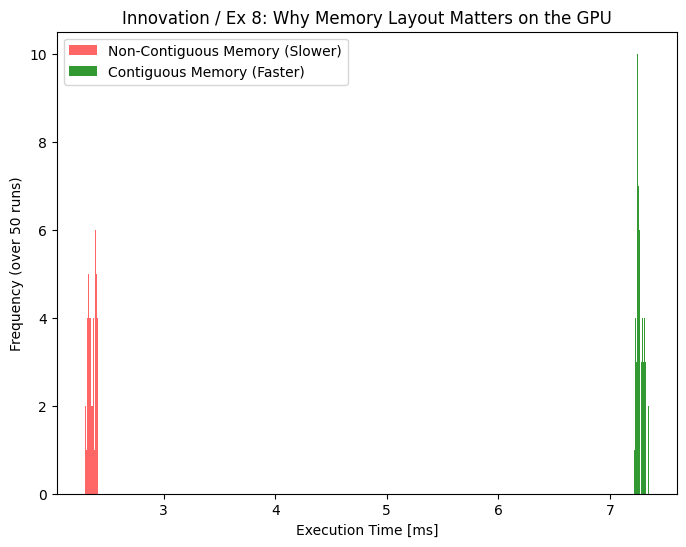

Observation: The red histogram (non-contiguous) is shifted to the right, meaning it takes longer.
The GPU struggles to fetch scattered memory. Forcing alignment speeds up the math!


In [20]:
# --- INNOVATION: Visualizing Memory Contiguity Impact (Solving Exercise 8) ---
# This block visually compares the runtime of operations on contiguous vs. non-contiguous memory.
# It proves why data layout is just as important as math in CUDA!

import matplotlib.pyplot as plt

# 1. Prepare the data: a large matrix and its non-contiguous transpose
test_tensor = torch.randn(8192, 8192, device=device)
non_contig_tensor = test_tensor.t() # Transposing makes it non-contiguous

# 2. Define the two operations
def op_non_contiguous():
    # Operates directly on the non-contiguous view
    return non_contig_tensor * 2.0

def op_contiguous():
    # Forces contiguous memory first, then operates
    contig = non_contig_tensor.contiguous()
    return contig * 2.0

# 3. Collect timings using the benchmark function defined earlier in the notebook
print("Benchmarking non-contiguous...")
times_non_contig = benchmark(op_non_contiguous, warmup=5, iters=50, label="Non-contiguous")

print("Benchmarking contiguous...")
times_contig = benchmark(op_contiguous, warmup=5, iters=50, label="Contiguous")

# 4. Plot the results to see the difference
fig, ax = plt.subplots(figsize=(8, 6))

# Plot non-contiguous times in red
ax.hist(times_non_contig, bins=15, alpha=0.6, color='red', label='Non-Contiguous Memory (Slower)')

# Plot contiguous times in green
ax.hist(times_contig, bins=15, alpha=0.8, color='green', label='Contiguous Memory (Faster)')

ax.set_xlabel("Execution Time [ms]")
ax.set_ylabel("Frequency (over 50 runs)")
ax.set_title("Innovation / Ex 8: Why Memory Layout Matters on the GPU")
ax.legend()

plt.show()

# Brief analysis printout
print("Observation: The red histogram (non-contiguous) is shifted to the right, meaning it takes longer.")
print("The GPU struggles to fetch scattered memory. Forcing alignment speeds up the math!")

## 20. Summary cheat sheet

### Core formulas

**1D global index**
\[
idx = blockIdx.x \cdot blockDim.x + threadIdx.x
\]

**Ceiling division for number of blocks**
\[
grid = \left\lceil \frac{N}{B} \right\rceil = \frac{N+B-1}{B}
\]

**2D flattening**
\[
flat = row \cdot W + col
\]

**3D flattening**
\[
flat = d(HW) + hW + w
\]

**Arithmetic intensity**
\[
AI = \frac{\text{flops}}{\text{bytes moved}}
\]

**First-order runtime model**
\[
T \approx \max\left(\frac{\text{bytes}}{BW}, \frac{\text{flops}}{F}\right)
\]

**Stable softmax**
\[
\operatorname{softmax}(x_i)=\frac{e^{x_i-m}}{\sum_j e^{x_j-m}}, \quad m=\max_j x_j
\]

**Scaled dot-product attention**
\[
\operatorname{Attention}(Q,K,V)=\operatorname{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V
\]

### Big ideas
- GPUs maximize **throughput**, not single-thread latency.
- CUDA performance depends heavily on **memory movement**.
- Many ML kernels are **memory-bound**.
- **Fusion** helps by reducing bytes moved and launch overhead.
- Always benchmark GPU code with **synchronization**.
- Trust the **profiler** more than your intuition.